In [1]:
import numpy as np 
import healpy as hp
import pandas as pd
import matplotlib.pyplot as plt
import tifffile as tiff
import glob
import seaborn as sns
# sns.set_style("darkgrid")
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from num2words import num2words
from scipy.optimize import curve_fit
from mpl_toolkits import mplot3d
import os
from distfit import distfit
import sys
import scipy
import rasterio
from scipy.interpolate import CubicSpline
from scipy.integrate import quad
from scipy.stats import multivariate_normal
# sns.set(rc={"xtick.bottom": True, "ytick.left": True})
%matplotlib inline
# %matplotlib notebook

In [2]:
Russia_total= 15508
China_total= 9333
Argentina_total =7092
Brazil_total=9201
Spain_total=6340
France_total=9406

## sample 5000 pixels from complete USA database

In [56]:
usa_data=pd.read_csv('./database/updated_USA_file_final.csv')

In [57]:
train_lon=usa_data['Longitude in degrees'].to_numpy()
train_lat=usa_data['Latitude in degrees'].to_numpy()
train_pix=hp.ang2pix(128,train_lon,train_lat,lonlat=True)

In [58]:
test_pix=np.random.choice(train_pix,5000,replace=False)
finlon,finlat=hp.pix2ang(128,test_pix,lonlat=True)
finlon[finlon>180]-=360

## CDF of pixels

In [59]:
tester=np.random.choice(test_pix,10,replace=False)
long,lat=hp.pix2ang(128,tester,lonlat=True)
long[long>180]-=360

In [60]:
data={'Lon':long,'Lat':lat}
df=pd.DataFrame(data)
df.to_csv('/home/pratush/Documents/USA_small.csv')

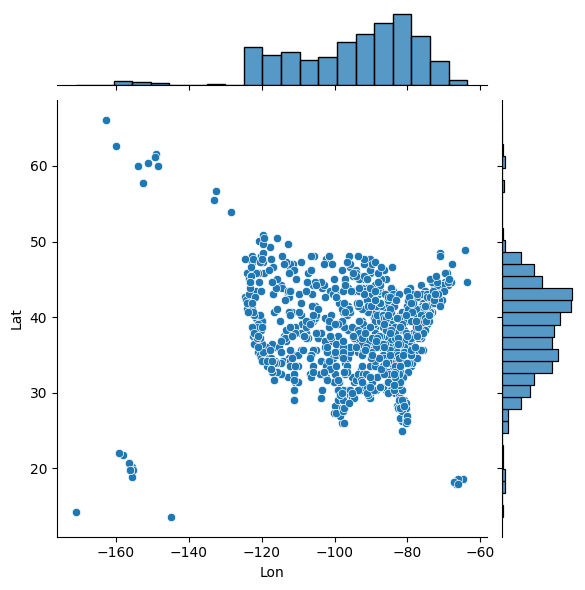

In [271]:
# Bin width using Freedman Diaconis rule
def FDrule(data):
    # Calculate interquartile range
    iqr = np.percentile(data, 75) - np.percentile(data, 25)
    
    # Calculate Freedman-Diaconis bin width
    n = len(data)
    bin_width = 2 * iqr / (n ** (1/3))

    # Calculate number of bins
    data_range = max(data) - min(data)
    num_bins = int(data_range / bin_width) + 1
    
    return num_bins

In [337]:
import numpy as np

data=np.column_stack((train_lon,train_lat))
jointProbs, edges = np.histogramdd(data, bins=100)
jointProbs /= jointProbs.sum()

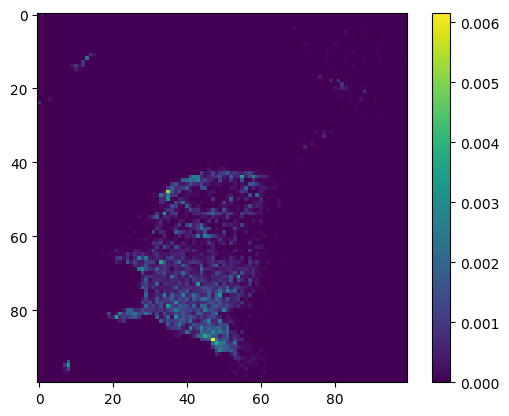

In [282]:
plt.imshow(jointProbs)
plt.colorbar()
plt.show()

In [300]:
a=.reshape(100,100)

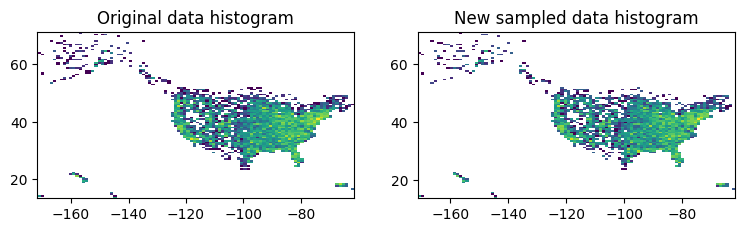

In [353]:
np.random.seed(42)
BIN_COUNT = 100

x, y = data.T

hist, x_bins, y_bins = np.histogram2d(x, y, bins=(BIN_COUNT, BIN_COUNT))
x_bin_midpoints = (x_bins[:-1] + x_bins[1:])/2
y_bin_midpoints = (y_bins[:-1] + y_bins[1:])/2

cdf = np.cumsum(hist.flatten())
cdf = cdf / cdf[-1]

values = np.random.rand(len(train_lat))
value_bins = np.searchsorted(cdf, values)
x_idx, y_idx = np.unravel_index(value_bins,
                                (len(x_bin_midpoints),
                                 len(y_bin_midpoints)))
random_from_cdf = np.column_stack((x_bin_midpoints[x_idx],
                                   y_bin_midpoints[y_idx]))
new_x, new_y = random_from_cdf.T


fig, axs = plt.subplots(1, 2, figsize=(9, 3))

axs[0].hist2d(x, y, bins=(BIN_COUNT, BIN_COUNT),norm='log')
axs[0].set_title('Original data histogram')
axs[1].hist2d(new_x, new_y, bins=(BIN_COUNT, BIN_COUNT),norm='log')
axs[1].set_title('New sampled data histogram')
for ax in axs:    
    ax.set(aspect='equal')
#     ax.set_axis_off()

In [342]:
# datums={'lon':new_x,'lat':new_y}
# df=pd.DataFrame(datums)
# df.to_csv('/home/pratush/Desktop/2dlatest.csv')

In [355]:
np.array_equal(new_x,train_lat)

False

In [363]:
np.random.rand(10)

array([0.18660622, 0.12711897, 0.58816411, 0.50637632, 0.6947891 ,
       0.30520726, 0.402368  , 0.02136107, 0.61014305, 0.42314352])